# 참외 병해 예측(분류) 모델 만들기

## 지능형 스마트팜(참외) 데이터
- [AI Hub 지능형 스마트팜(참외) 데이터](https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=&topMenu=&aihubDataSe=data&dataSetSn=71344)
- 참외 재배 시 발생하는 노균병, 흰가루병의 진단을 목적으로 노균병, 노균병유사, 흰가루병, 흰가루병유사, 정상 이미지를 인공지능 학습하여 질병과 질병의 유사 형상 및 정상 이미지를 비교해 질병의 정확한 진단을 가능하게 함

**corps_info**
- set_meal_dt: 식사 세트 날짜 (비료나 물을 준 날짜)
- grdp_step: 생육 단계

**image**
- class_name: 병해 유형 이름

**environments** : 각 환경 요소에 대한 데이터가 시간별로 기록
- evrmnt_id: 환경 데이터의 ID
- inr_tp: 내부 온도 (°C)
- inr_hd: 내부 습도 (%)
- co2: CO2 농도 (ppm)
- amnt_of_slr_rdt: 일사량 (W/m²)
- soil_ec: 토양 전기 전도도 (dS/m)
- soil_tp: 토양 온도 (°C)
- soil_hd: 토양 습도 (%)
- rain: 강수 유무
- extrnl_tp: 외부 온도 (°C)
- extrnl_hd: 외부 습도 (%)
- receive_dt: 데이터 수신 시간

# 데이터 분석 기본 단계 흐름

1. 데이터 수집
2. 데이터 전처리
   - 결측치 처리
    - 이상치 제거 또는 보정
    - 타입 변환 (datetime, float, category 등)
    - 필요 시 스케일링/로그 변환
3. 탐색적 데이터 분석 (EDA)
    - describe, groupby, 시각화 등
4. 통계적 분석 (예: ANOVA)
5. 모델링/예측 또는 인사이트 도출
6. 결론 요약 및 시각화 보고서 작성



## 0. 라이브러리 임포트

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

## 1. 데이터 가져오기

In [24]:
melon_path = './file/melon_environment.csv'
df = pd.read_csv(melon_path)

# 데이터프레임 출력
print(df)

       병해 유형 생육 단계  내부 온도  내부 습도  CO2 농도  일사량  토양 전기 전도도  토양 온도  토양 습도 강수 유무  \
0        노균병    정식   40.7   49.3     389  218       0.38   30.6   26.7    맑음   
1        노균병    정식   39.7   56.9     394  314       0.37   30.8   26.4    맑음   
2        노균병    정식   26.4   85.9     423   28       0.18   30.2   21.6    맑음   
3        노균병    정식   27.2   85.7     419   45       0.18   30.1   21.6    맑음   
4        노균병    정식   42.7   37.5     409  295       0.16   31.7   21.3    맑음   
...      ...   ...    ...    ...     ...  ...        ...    ...    ...   ...   
7275  흰가루병유사    착과   24.6   94.0     529    0       0.09   29.7   16.9    맑음   
7276  흰가루병유사    착과   26.1   82.8     393    0       0.16   28.4   22.0    맑음   
7277  흰가루병유사    착과   26.1   82.5     392    0       0.16   28.4   22.0    맑음   
7278  흰가루병유사    착과   27.3   78.8     378    0       0.14   29.5   21.0    맑음   
7279  흰가루병유사    착과   27.1   78.5     381    0       0.14   29.5   21.0    맑음   

      외부 온도  외부 습도             데이터 수신시간

## 2. 데이터 훑어보기

In [25]:
# 상위 5개 행
print(df.head())

  병해 유형 생육 단계  내부 온도  내부 습도  CO2 농도  일사량  토양 전기 전도도  토양 온도  토양 습도 강수 유무  \
0   노균병    정식   40.7   49.3     389  218       0.38   30.6   26.7    맑음   
1   노균병    정식   39.7   56.9     394  314       0.37   30.8   26.4    맑음   
2   노균병    정식   26.4   85.9     423   28       0.18   30.2   21.6    맑음   
3   노균병    정식   27.2   85.7     419   45       0.18   30.1   21.6    맑음   
4   노균병    정식   42.7   37.5     409  295       0.16   31.7   21.3    맑음   

   외부 온도  외부 습도             데이터 수신시간  
0   27.0   75.0  2022-07-05 12:00:00  
1   27.0   75.0  2022-07-05 12:30:00  
2   33.0   50.0  2022-07-06 06:00:00  
3   33.0   50.0  2022-07-06 06:30:00  
4   27.0   75.0  2022-07-07 15:00:00  


In [26]:
# 데이터프레임의 요약 정보
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7280 entries, 0 to 7279
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   병해 유형      7280 non-null   object 
 1   생육 단계      7280 non-null   object 
 2   내부 온도      7280 non-null   float64
 3   내부 습도      7280 non-null   float64
 4   CO2 농도     7280 non-null   int64  
 5   일사량        7280 non-null   int64  
 6   토양 전기 전도도  7280 non-null   float64
 7   토양 온도      7280 non-null   float64
 8   토양 습도      7280 non-null   float64
 9   강수 유무      7280 non-null   object 
 10  외부 온도      7280 non-null   float64
 11  외부 습도      7280 non-null   float64
 12  데이터 수신시간   7280 non-null   object 
dtypes: float64(7), int64(2), object(4)
memory usage: 739.5+ KB
None


In [27]:
# 3. 기초 통계량 확인
print(df.describe())

             내부 온도        내부 습도       CO2 농도          일사량    토양 전기 전도도  \
count  7280.000000  7280.000000  7280.000000  7280.000000  7280.000000   
mean     29.744409    70.145701   451.483654   122.190247     0.310272   
std       8.786040    21.930567   202.454348   160.459740     0.347421   
min       5.500000    13.100000   169.000000   -10.000000     0.020000   
25%      24.700000    51.100000   370.000000     0.000000     0.090000   
50%      27.300000    78.100000   411.000000    39.000000     0.140000   
75%      35.225000    88.600000   459.000000   225.000000     0.390000   
max      57.400000   100.000000  2567.000000   822.000000     1.180000   

             토양 온도        토양 습도        외부 온도        외부 습도  
count  7280.000000  7280.000000  7280.000000  7280.000000  
mean     28.126442    23.377596    21.840179    67.311538  
std       3.284812     9.344153    56.452307    60.798577  
min      18.600000    11.800000  -999.000000  -998.000000  
25%      25.600000    17.200000  

In [28]:
# 컬럼명 목록 확인
print(df.columns)

Index(['병해 유형', '생육 단계', '내부 온도', '내부 습도', 'CO2 농도', '일사량', '토양 전기 전도도',
       '토양 온도', '토양 습도', '강수 유무', '외부 온도', '외부 습도', '데이터 수신시간'],
      dtype='object')


In [29]:
# 결측치 확인
print(df.isnull().sum())

병해 유형        0
생육 단계        0
내부 온도        0
내부 습도        0
CO2 농도       0
일사량          0
토양 전기 전도도    0
토양 온도        0
토양 습도        0
강수 유무        0
외부 온도        0
외부 습도        0
데이터 수신시간     0
dtype: int64


In [30]:
# 데이터 타입 확인
print(df.dtypes)

병해 유형         object
생육 단계         object
내부 온도        float64
내부 습도        float64
CO2 농도         int64
일사량            int64
토양 전기 전도도    float64
토양 온도        float64
토양 습도        float64
강수 유무         object
외부 온도        float64
외부 습도        float64
데이터 수신시간      object
dtype: object


In [31]:
# 데이터프레임의 크기 (행, 열 수)
print(df.shape)

(7280, 13)


## 3. 데이터 탐색

### 범주형 특성 탐색

In [32]:
# 범주형 변수 추출
categorical_cols = df.select_dtypes(include=['object']).columns

# 각 범주형 변수에 대해 고유값, 빈도수 등 확인
for col in categorical_cols:
    print(f'- Column: {col}')
    print(df[col].value_counts())
    print('고유값 개수:', df[col].nunique())
    print('-' * 40)

- Column: 병해 유형
병해 유형
정상        3040
노균병       1460
흰가루병      1460
노균병유사      660
흰가루병유사     660
Name: count, dtype: int64
고유값 개수: 5
----------------------------------------
- Column: 생육 단계
생육 단계
정식    3304
수확    2422
착과    1554
Name: count, dtype: int64
고유값 개수: 3
----------------------------------------
- Column: 강수 유무
강수 유무
맑음    7095
비      185
Name: count, dtype: int64
고유값 개수: 2
----------------------------------------
- Column: 데이터 수신시간
데이터 수신시간
2022-07-04 22:30:00    15
2022-07-04 22:00:00    15
2022-07-01 23:00:00    14
2022-06-26 12:00:00    14
2022-07-04 03:00:00    14
                       ..
2022-07-01 15:00:00     1
2022-06-30 21:30:00     1
2022-07-12 20:30:00     1
2022-07-10 02:00:00     1
2022-08-08 03:00:00     1
Name: count, Length: 2755, dtype: int64
고유값 개수: 2755
----------------------------------------


### 수치형 특성 탐색

Index(['내부 온도', '내부 습도', 'CO2 농도', '일사량', '토양 전기 전도도', '토양 온도', '토양 습도',
       '외부 온도', '외부 습도'],
      dtype='object')
             내부 온도        내부 습도       CO2 농도          일사량    토양 전기 전도도  \
count  7280.000000  7280.000000  7280.000000  7280.000000  7280.000000   
mean     29.744409    70.145701   451.483654   122.190247     0.310272   
std       8.786040    21.930567   202.454348   160.459740     0.347421   
min       5.500000    13.100000   169.000000   -10.000000     0.020000   
25%      24.700000    51.100000   370.000000     0.000000     0.090000   
50%      27.300000    78.100000   411.000000    39.000000     0.140000   
75%      35.225000    88.600000   459.000000   225.000000     0.390000   
max      57.400000   100.000000  2567.000000   822.000000     1.180000   

             토양 온도        토양 습도        외부 온도        외부 습도  
count  7280.000000  7280.000000  7280.000000  7280.000000  
mean     28.126442    23.377596    21.840179    67.311538  
std       3.284812     9.344153 

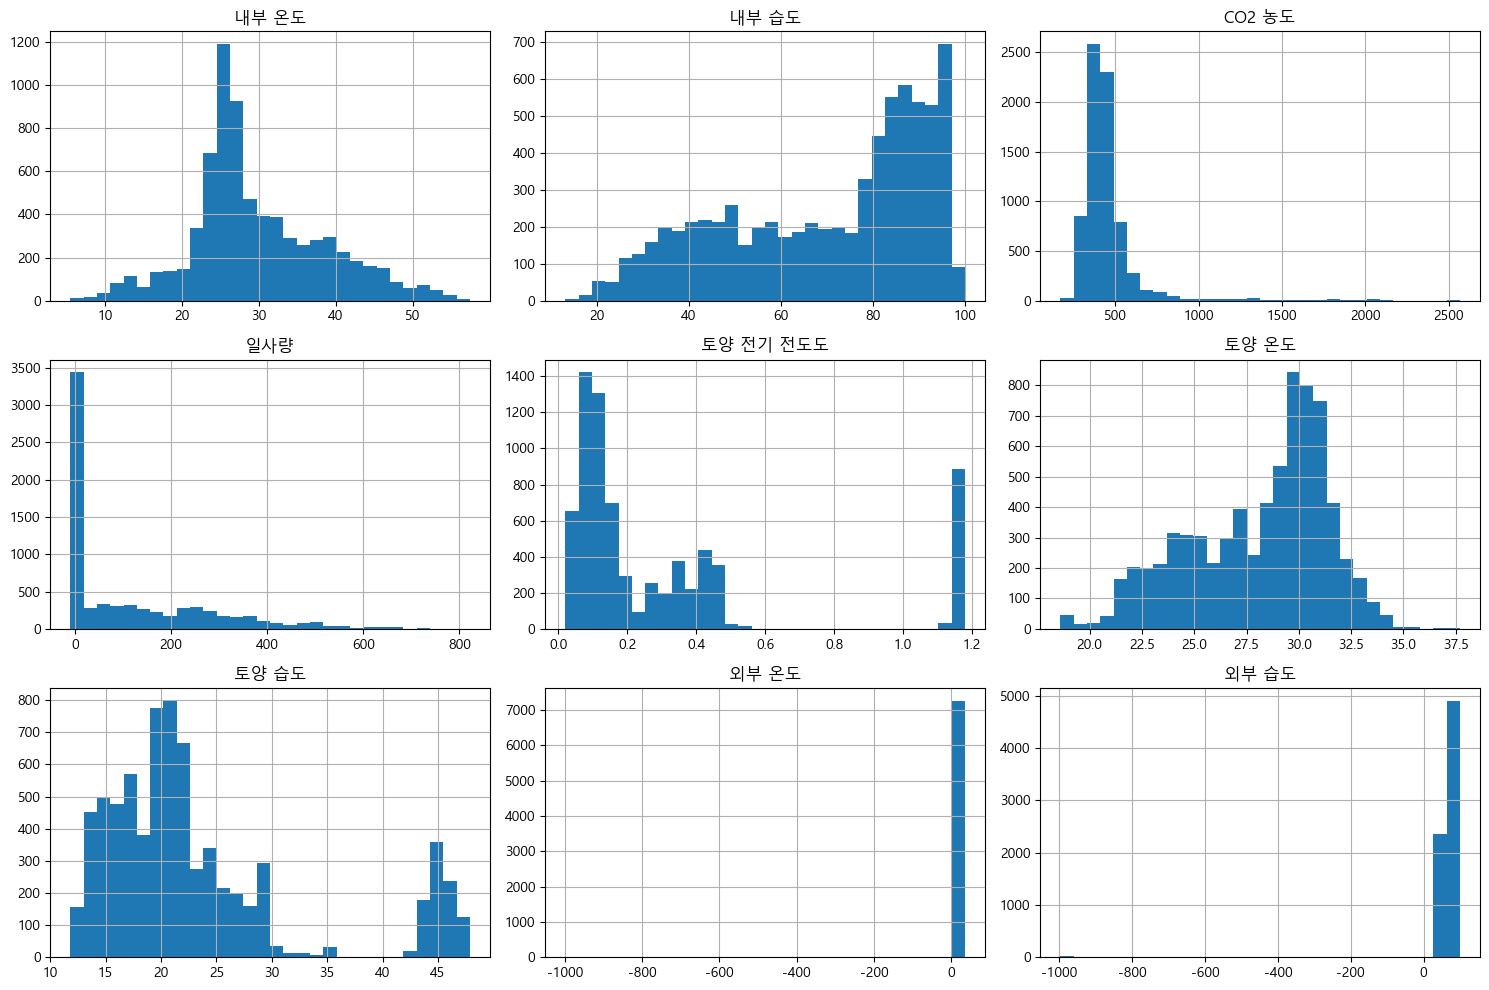

In [33]:
# 수치형 변수 추출
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_cols)

# 기초 통계량 확인
print(df[numerical_cols].describe())

# 한글 폰트 설정 (예: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

### 데이터 관계 시각화

#### - 산점도

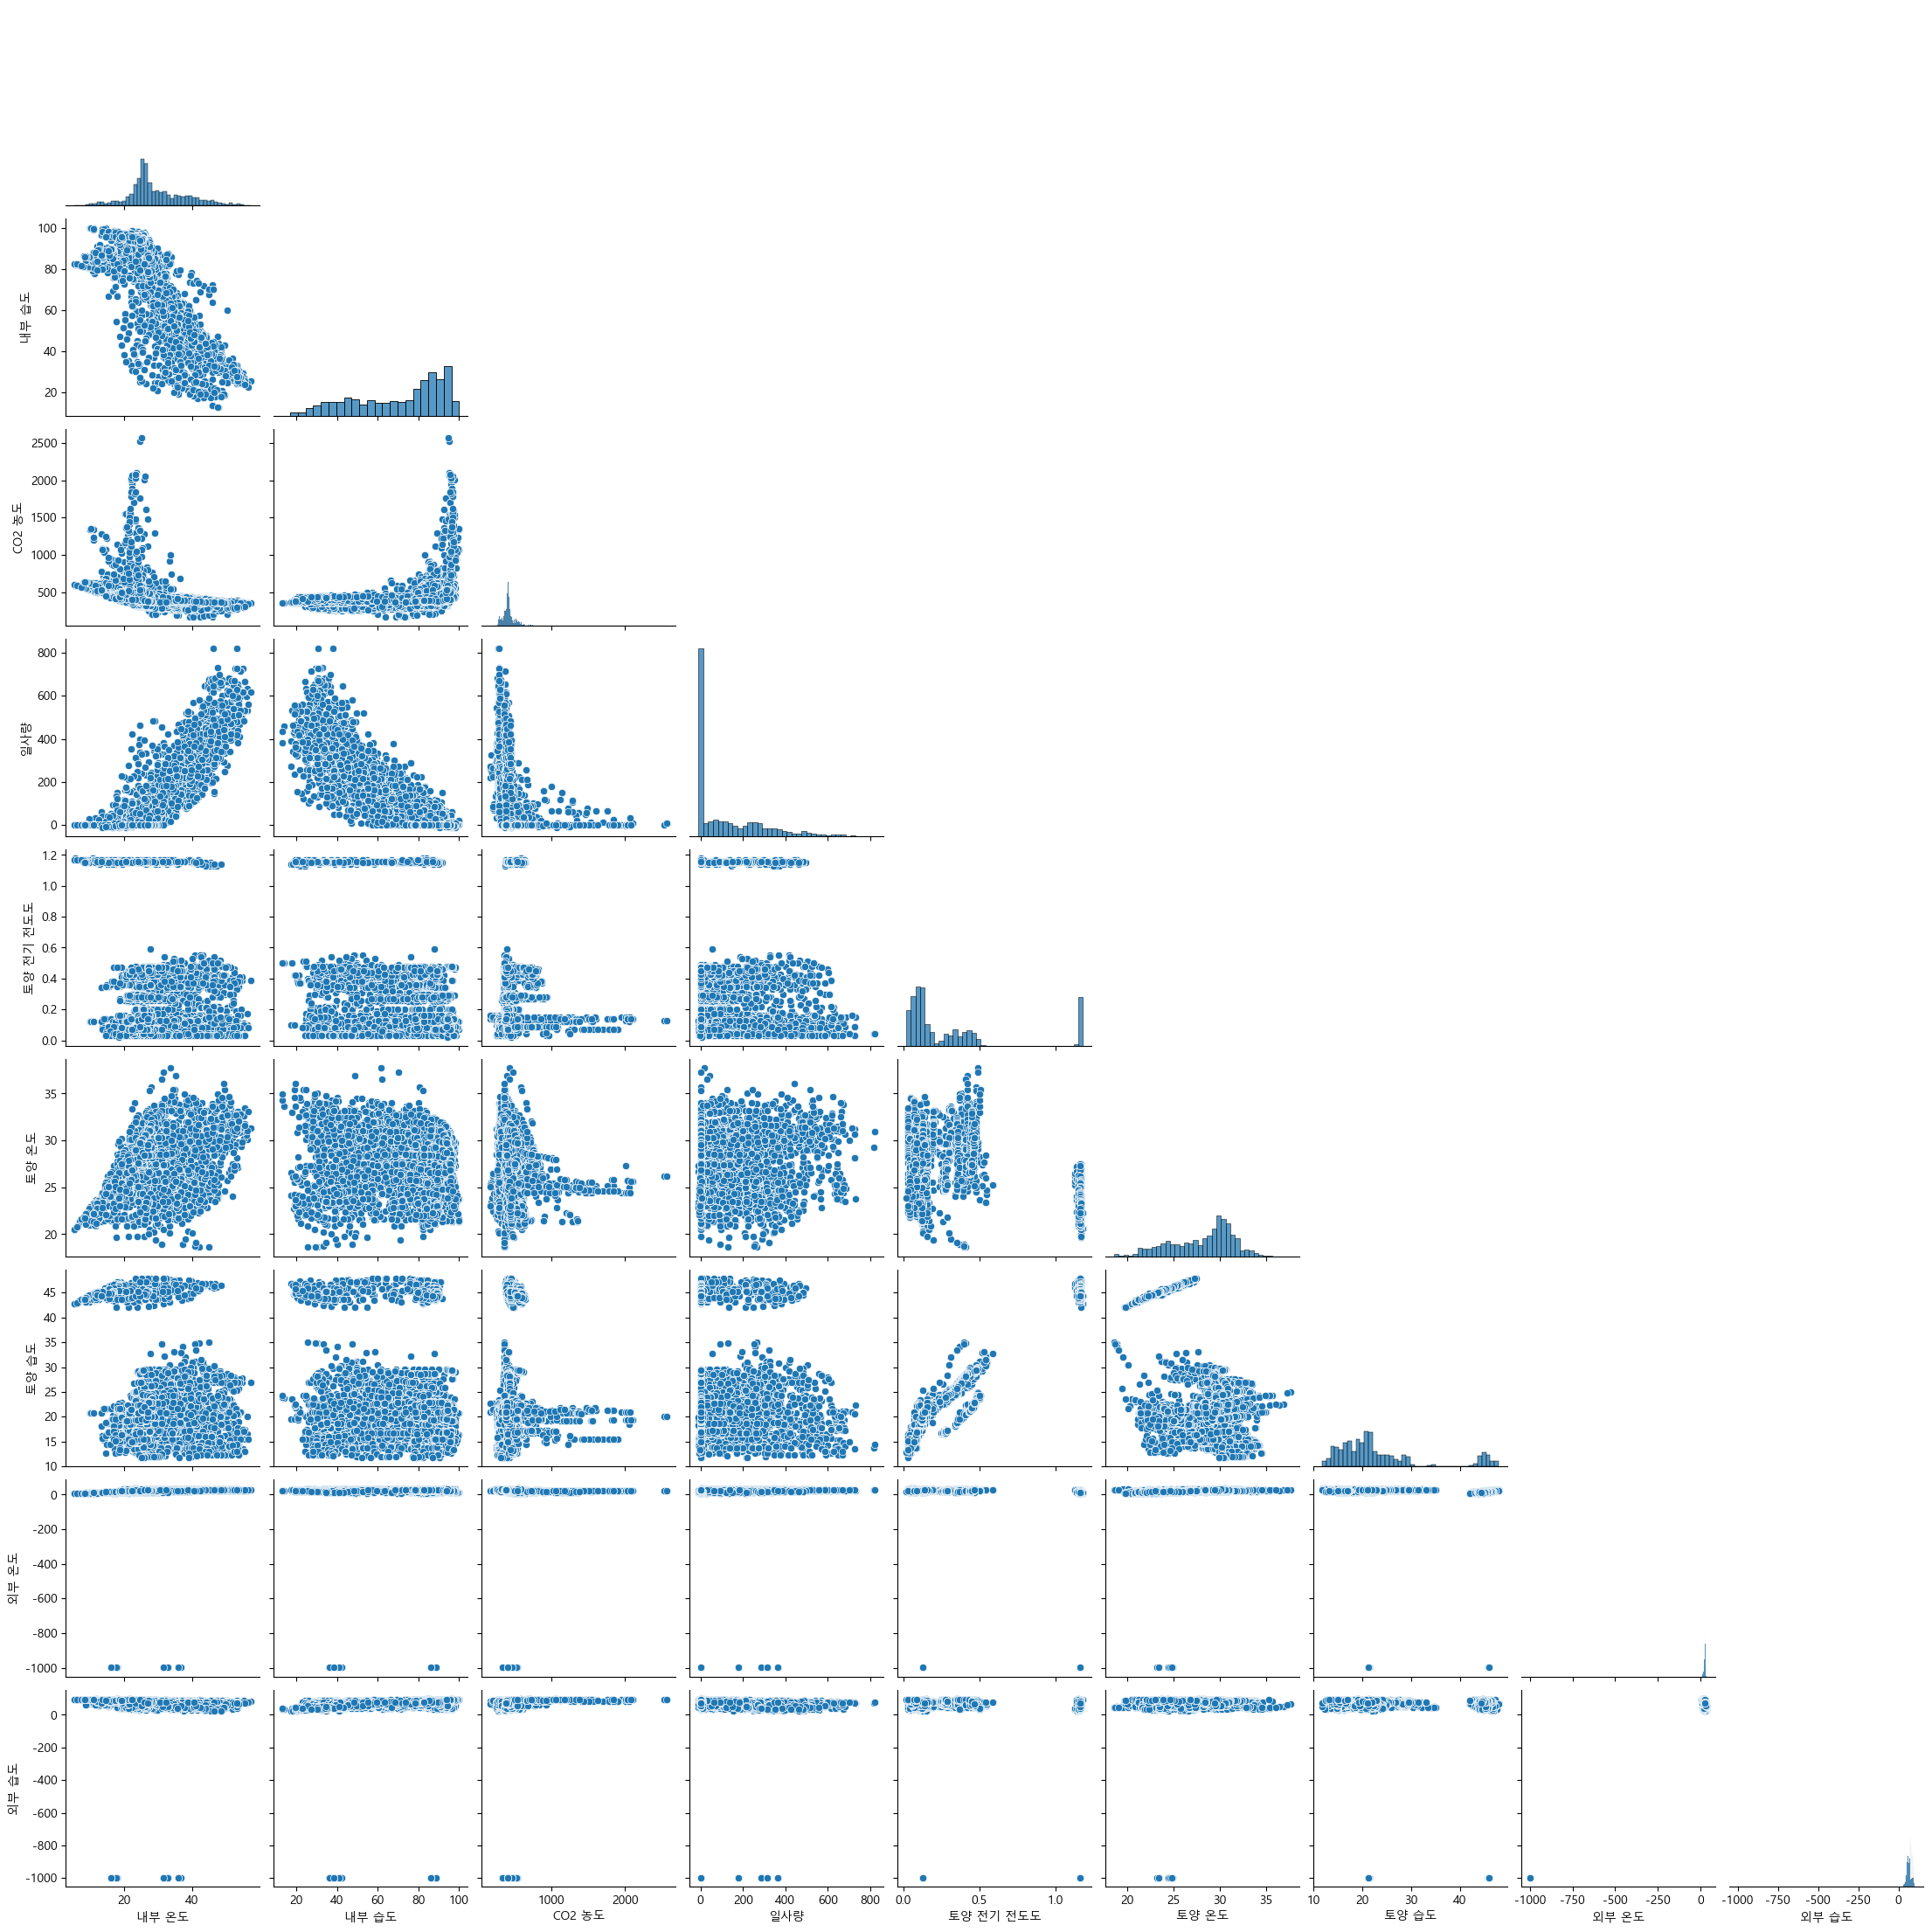

In [34]:
# 수치형 변수만 선택
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# 산점도
sns.pairplot(numerical_df, corner=True)
plt.show()

#### - 상관계수 히트맵

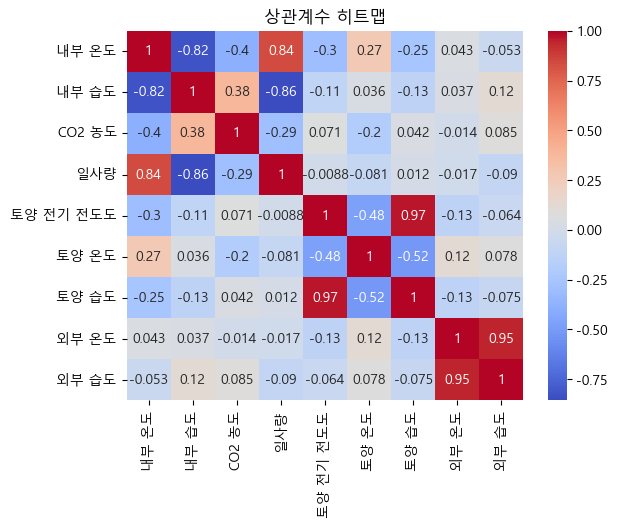

In [35]:
corr = df.corr(numeric_only=True)  # 수치형만 상관계수 계산
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('상관계수 히트맵')
plt.show()

#### - 박스 플롯

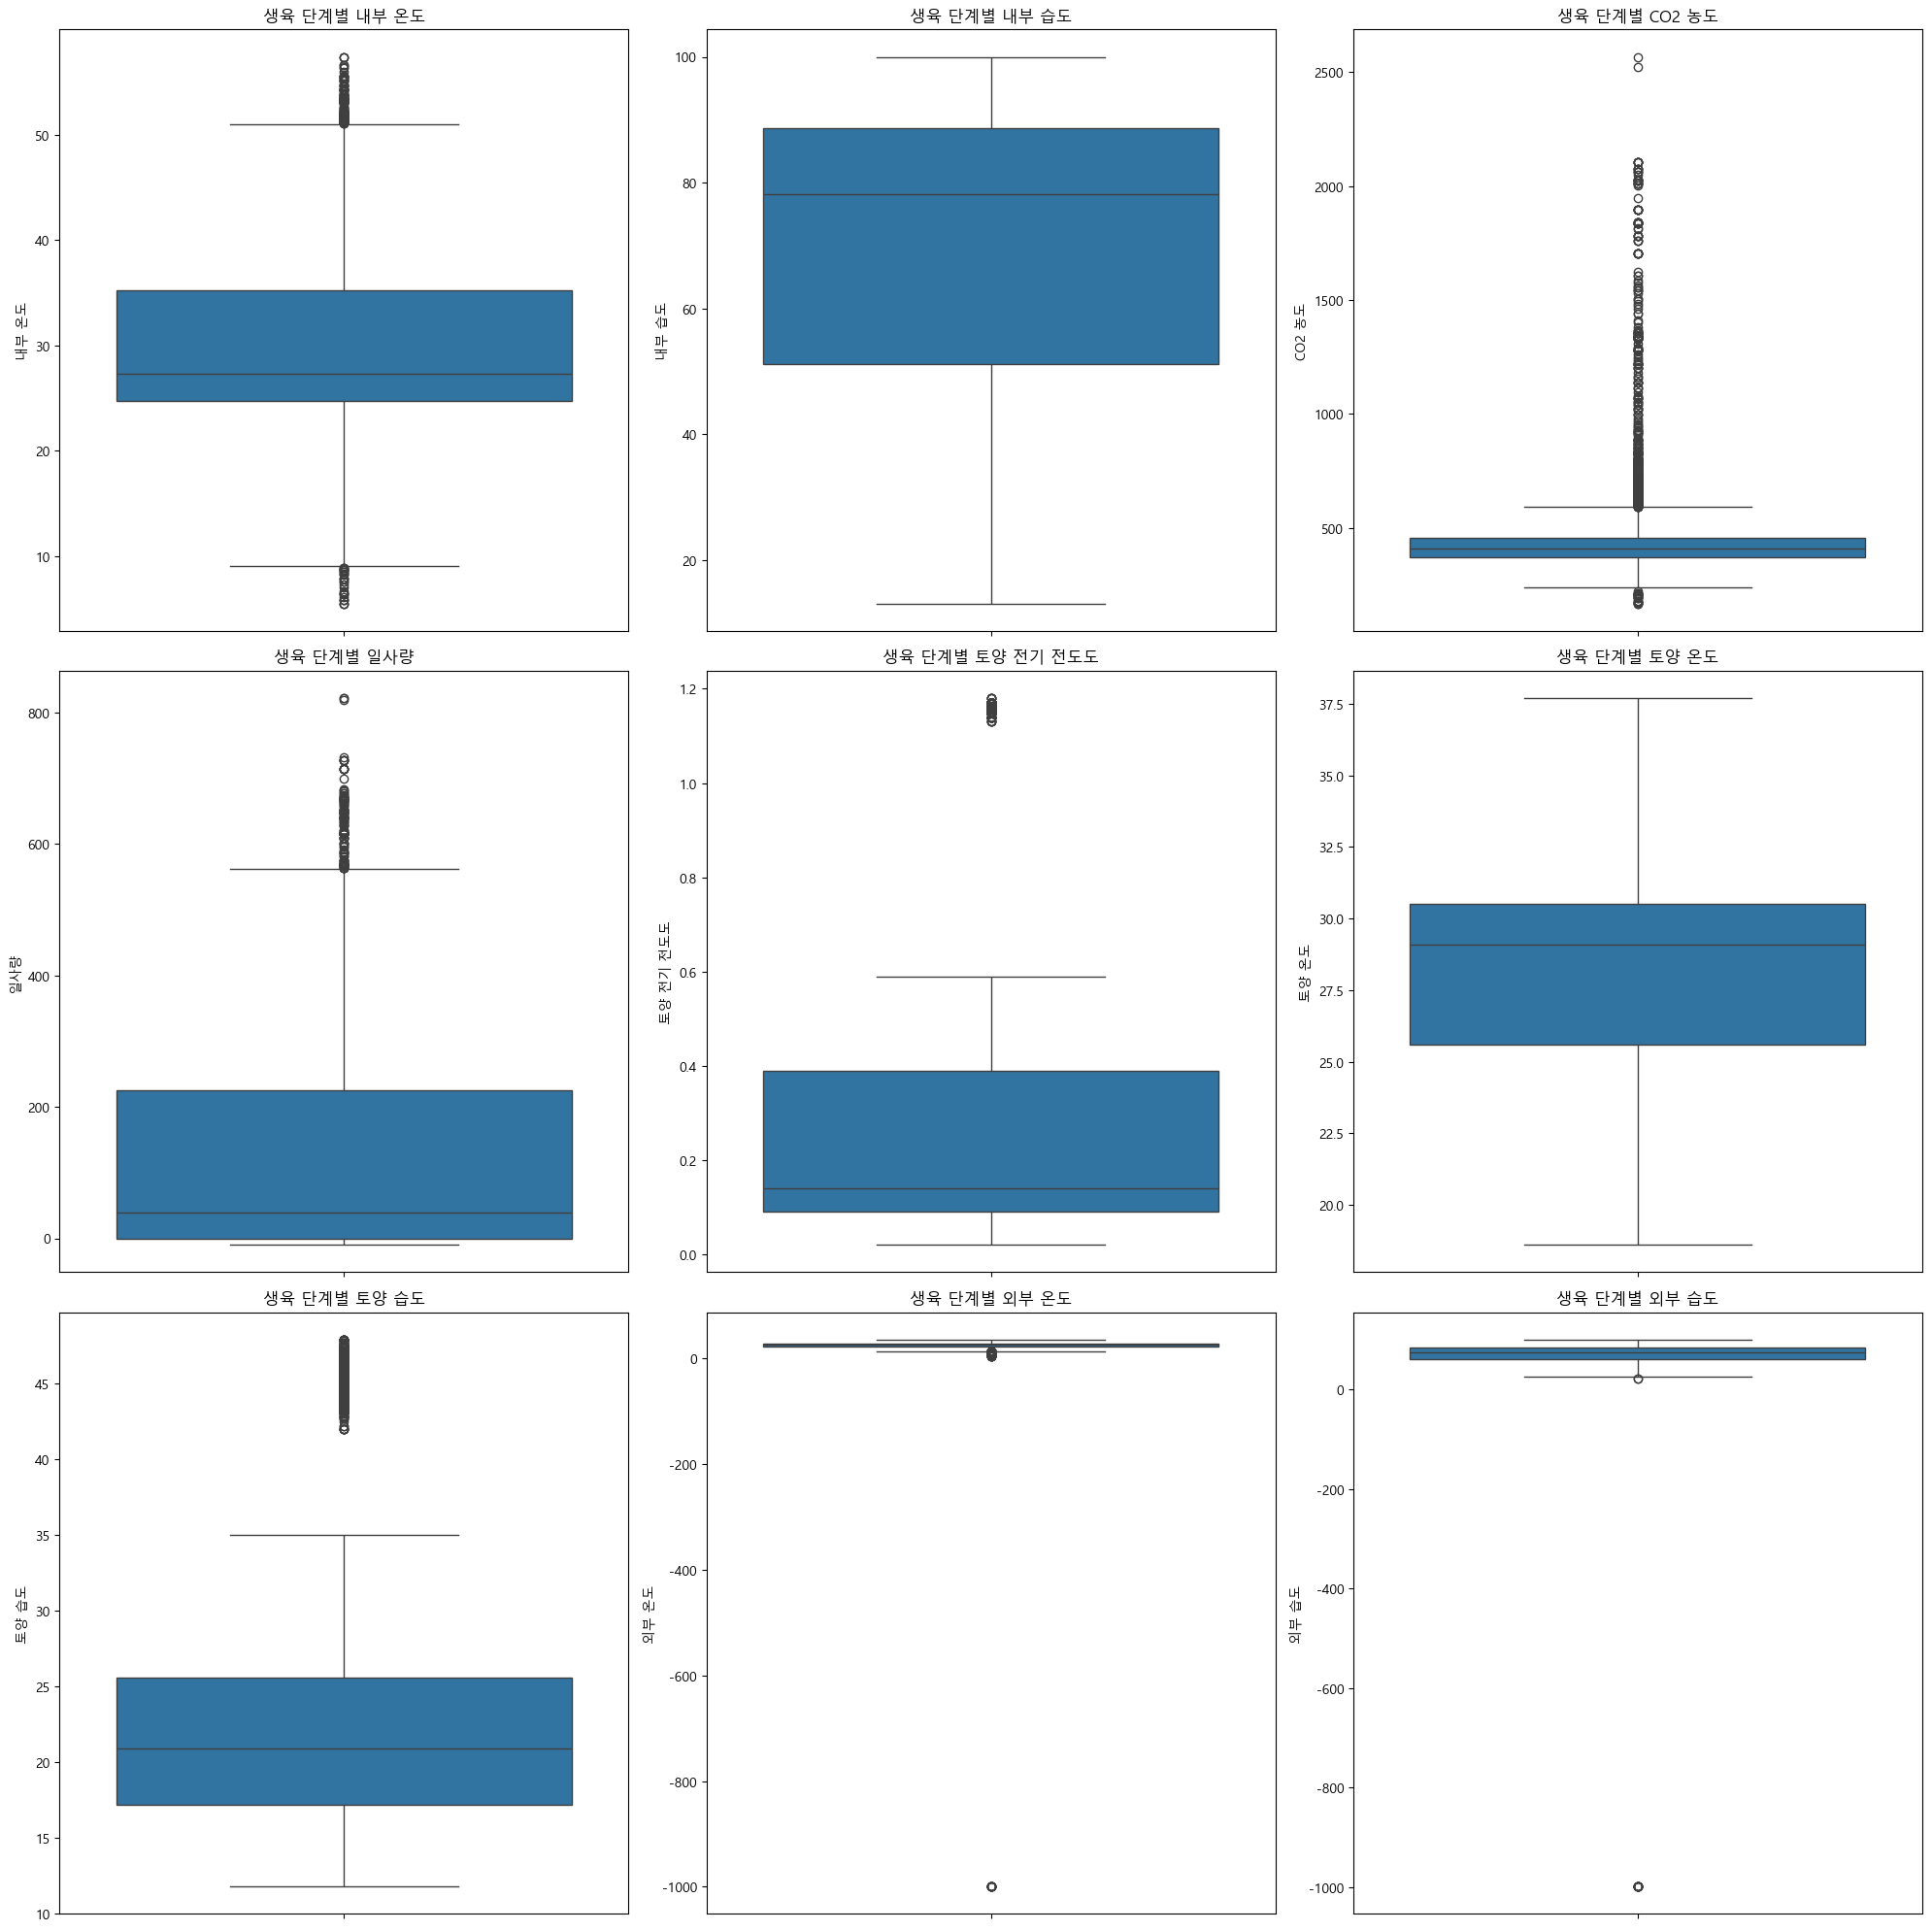

In [41]:
numerical_cols_lst = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

#  기준이 되는 범주형 변수 (예: 생육 단계 또는 강수 유무)
target_column = '생육 단계'  # 또는 '강수 유무'

# subplot 만들기 (3행 3열)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
axes = axes.flatten()

# 박스플롯 반복
for i, col in enumerate(numerical_cols_lst):
    sns.boxplot(y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{target_column}별 {col}')
    axes[i].tick_params(axis='x', rotation=45)  # x축 범주 회전

plt.tight_layout()
plt.show()

#### - 시계열 데이터

In [37]:
# '데이터 수신시간' 컬럼을 datetime 타입으로 변환
df['데이터 수신시간'] = pd.to_datetime(df['데이터 수신시간'])

# 시간 기준 정렬 (필수!)
df = df.sort_values('데이터 수신시간')
df.head()

,병해 유형,생육 단계,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,강수 유무,외부 온도,외부 습도,데이터 수신시간
4388,정상,정식,27.7,71.0,314,0,0.06,31.3,15.7,맑음,23.0,80.0,2022-06-25 19:30:00
4389,정상,정식,27.0,72.1,320,0,0.06,31.1,15.7,맑음,22.0,90.0,2022-06-25 20:00:00
3040,정상,정식,26.7,72.6,413,0,0.35,32.4,25.1,맑음,22.0,90.0,2022-06-25 20:00:00
2874,정상,정식,26.3,73.2,420,0,0.35,32.2,25.1,맑음,22.0,90.0,2022-06-25 20:30:00
2872,정상,정식,26.3,73.2,420,0,0.35,32.2,25.1,맑음,22.0,90.0,2022-06-25 20:30:00


<Figure size 1500x600 with 0 Axes>

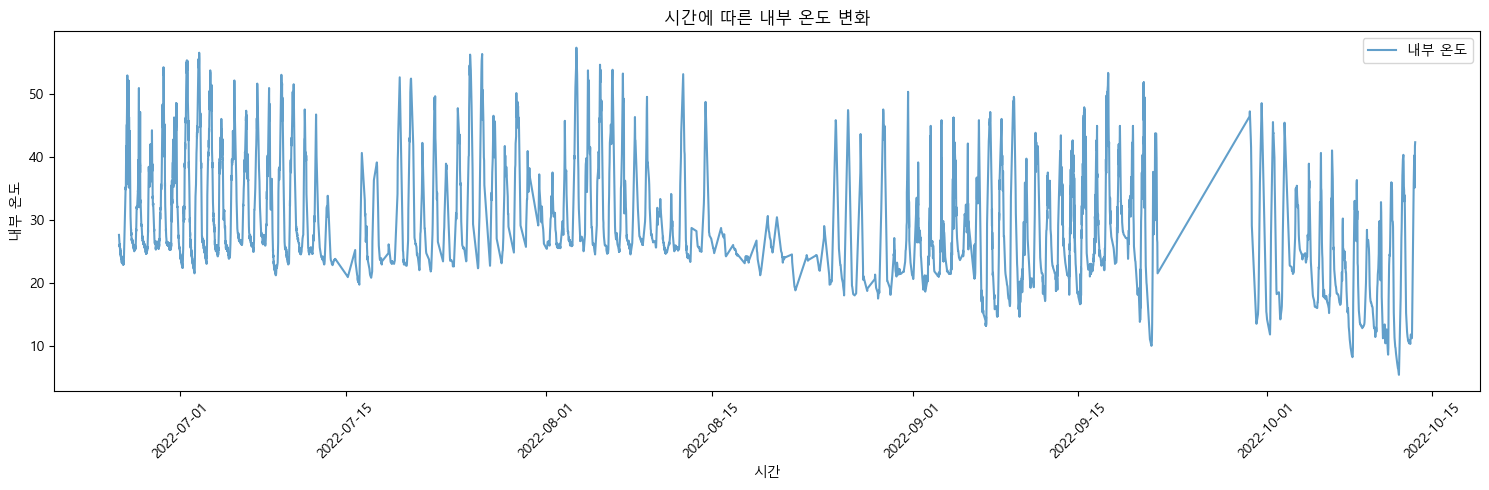

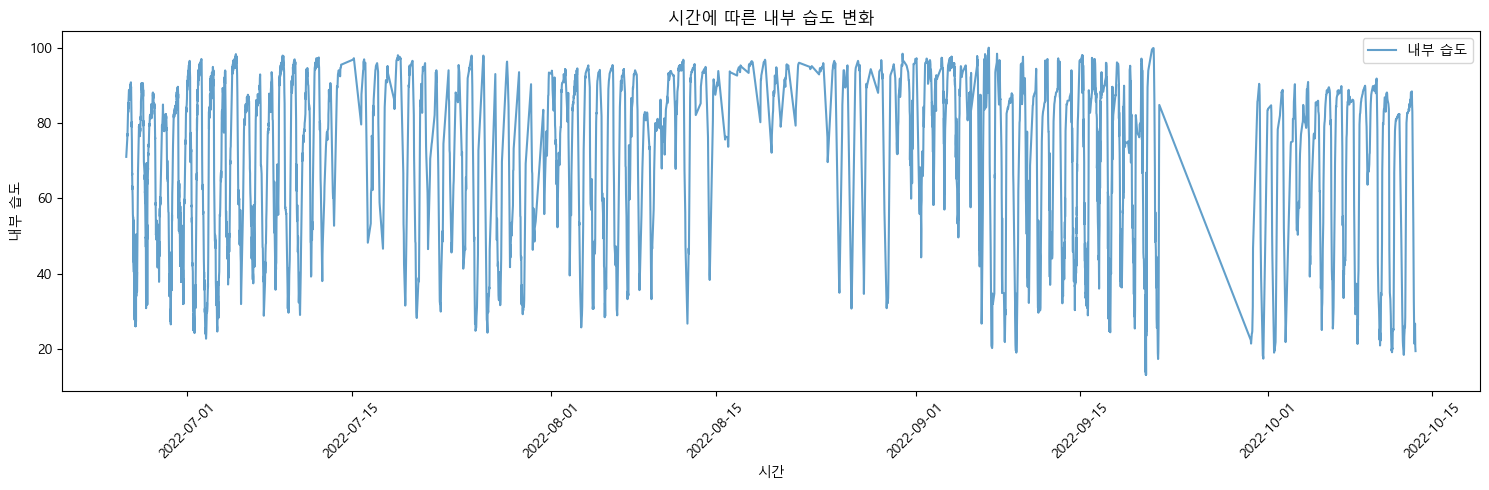

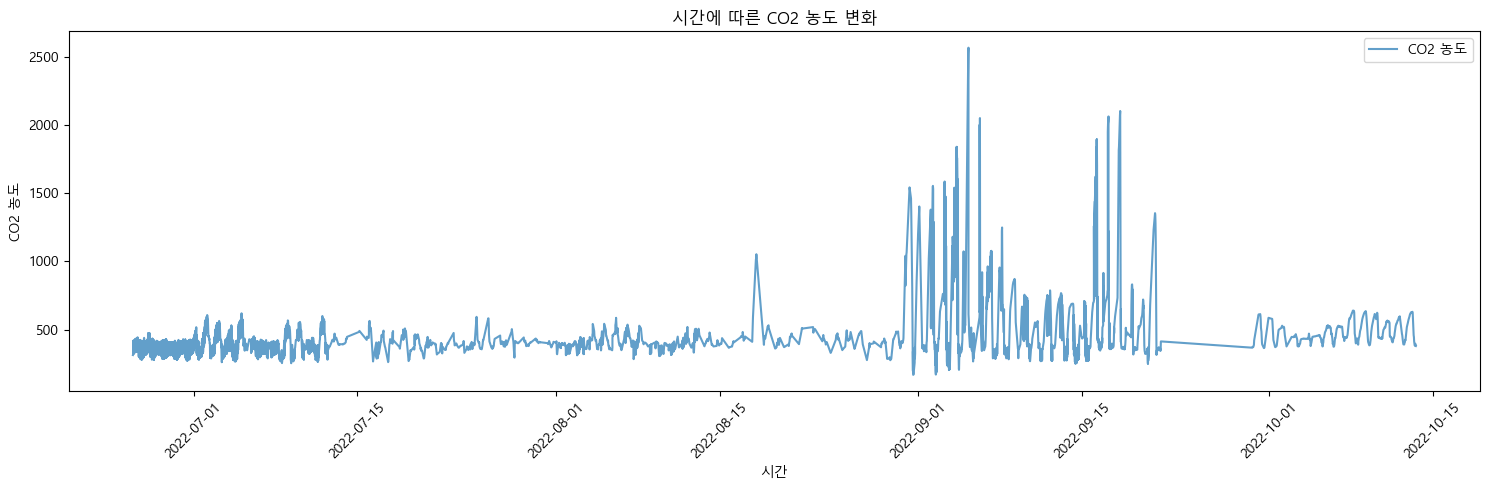

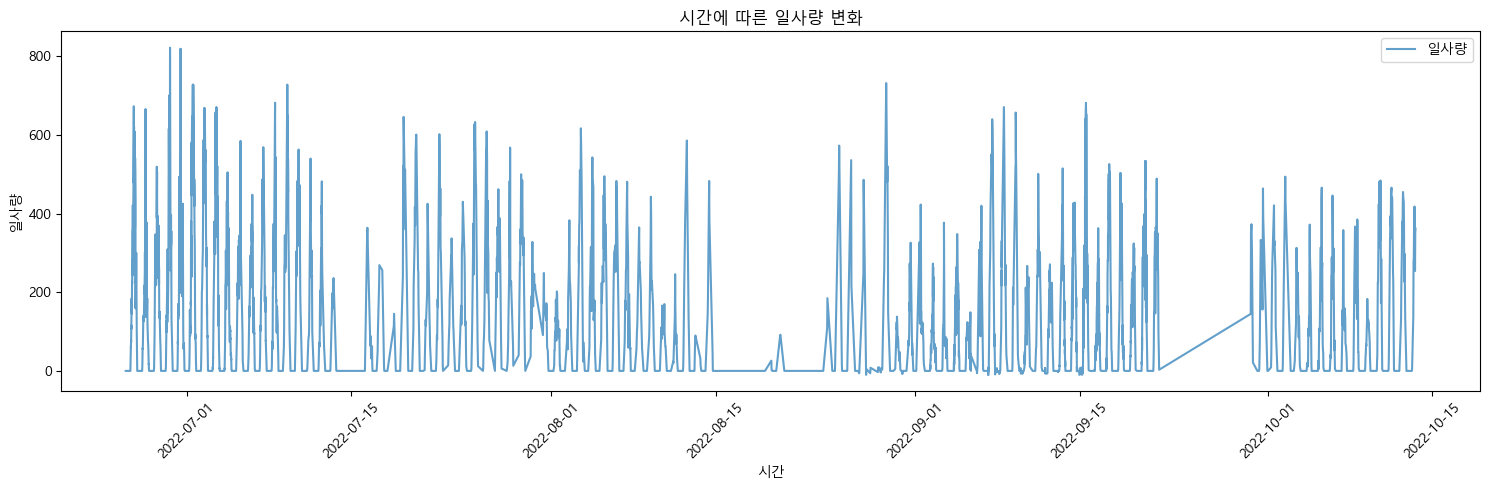

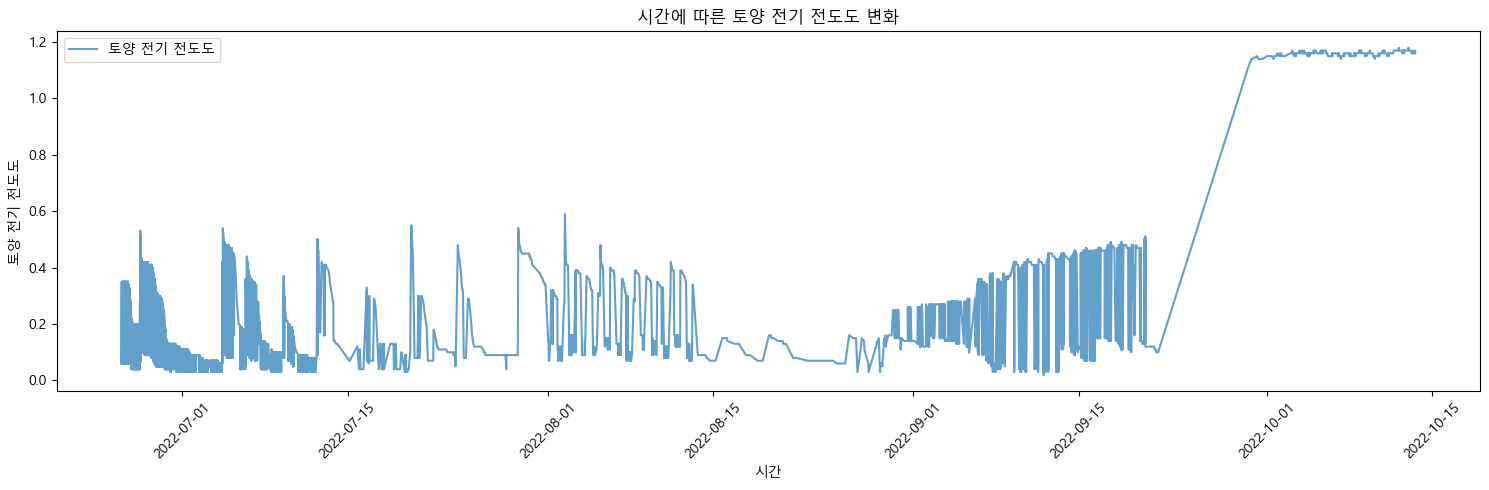

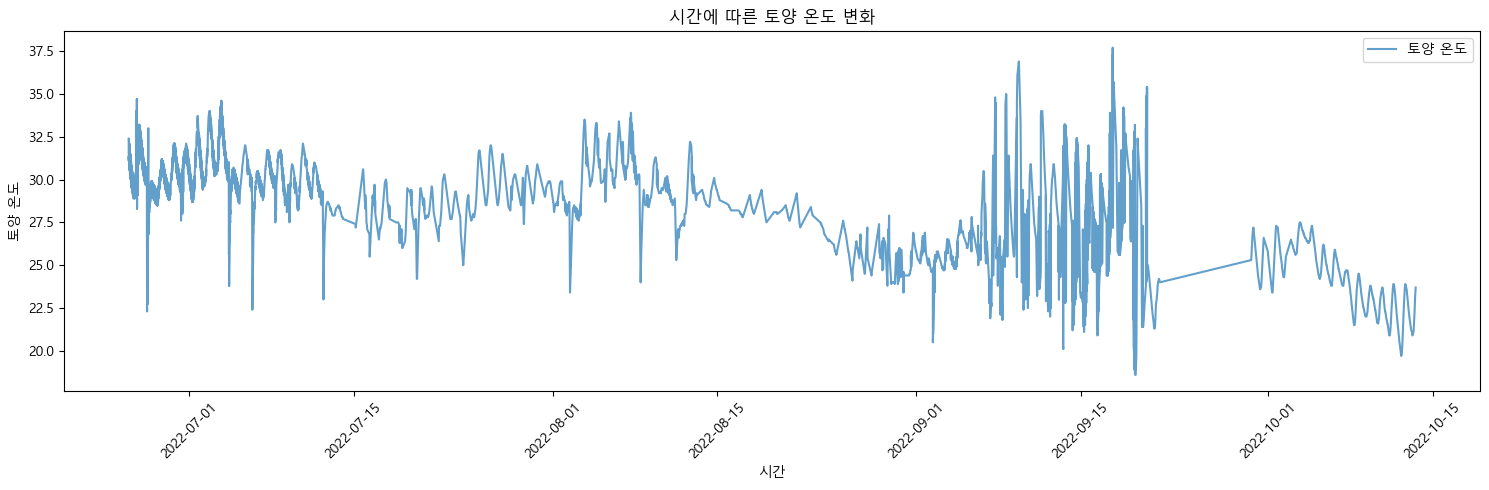

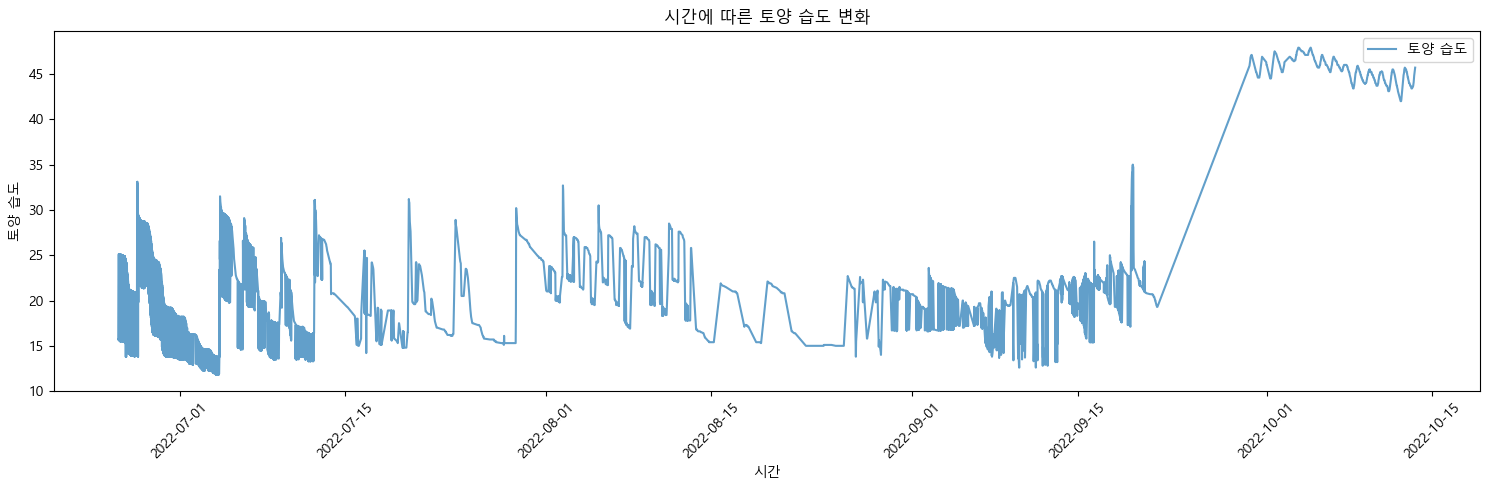

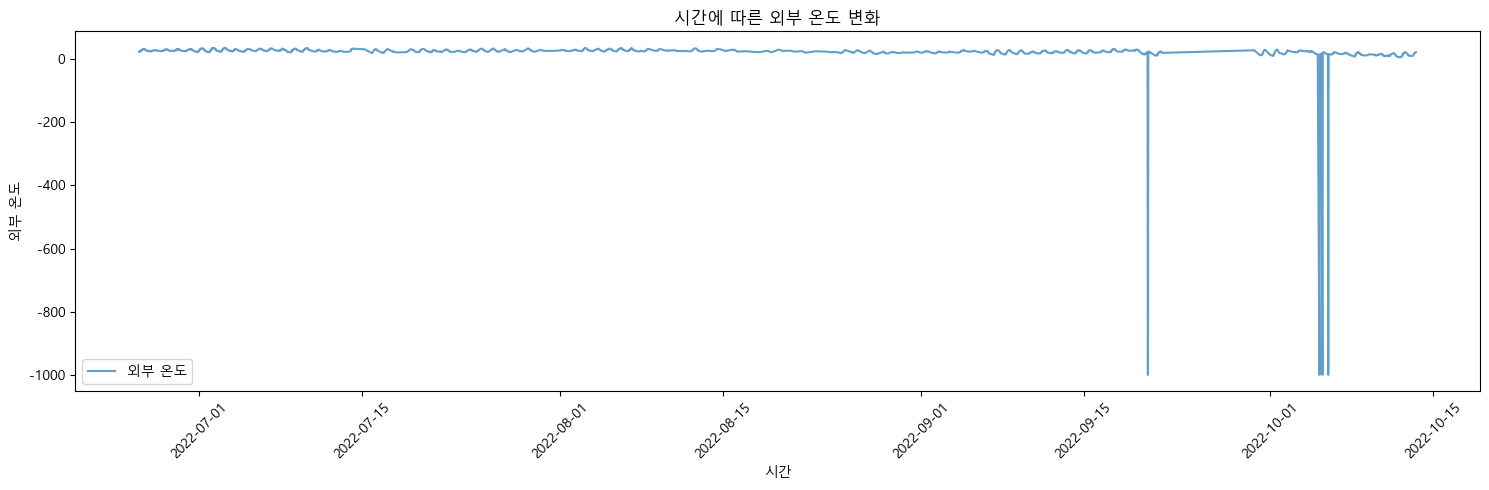

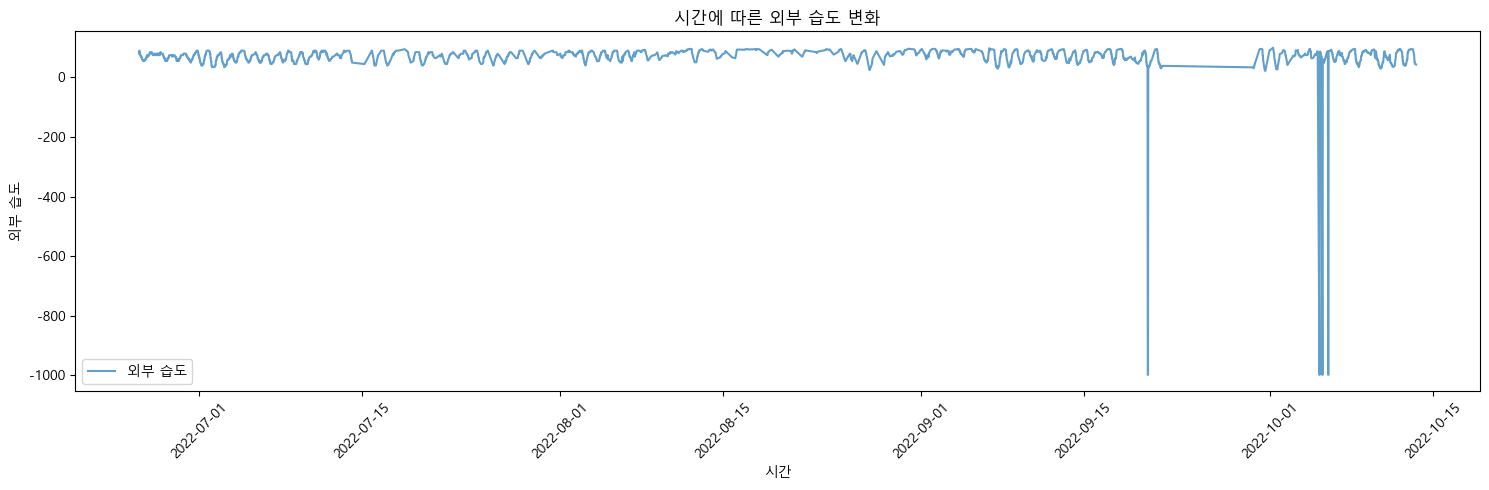

In [38]:

plt.figure(figsize=(15, 6))
for col in numerical_cols_lst:
    plt.figure(figsize=(15, 5))
    plt.plot(df['데이터 수신시간'], df[col], label=col, alpha=0.7)
    plt.title(f'시간에 따른 {col} 변화')
    plt.xlabel('시간')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### - 병해 유형(타깃)별 환경 특성

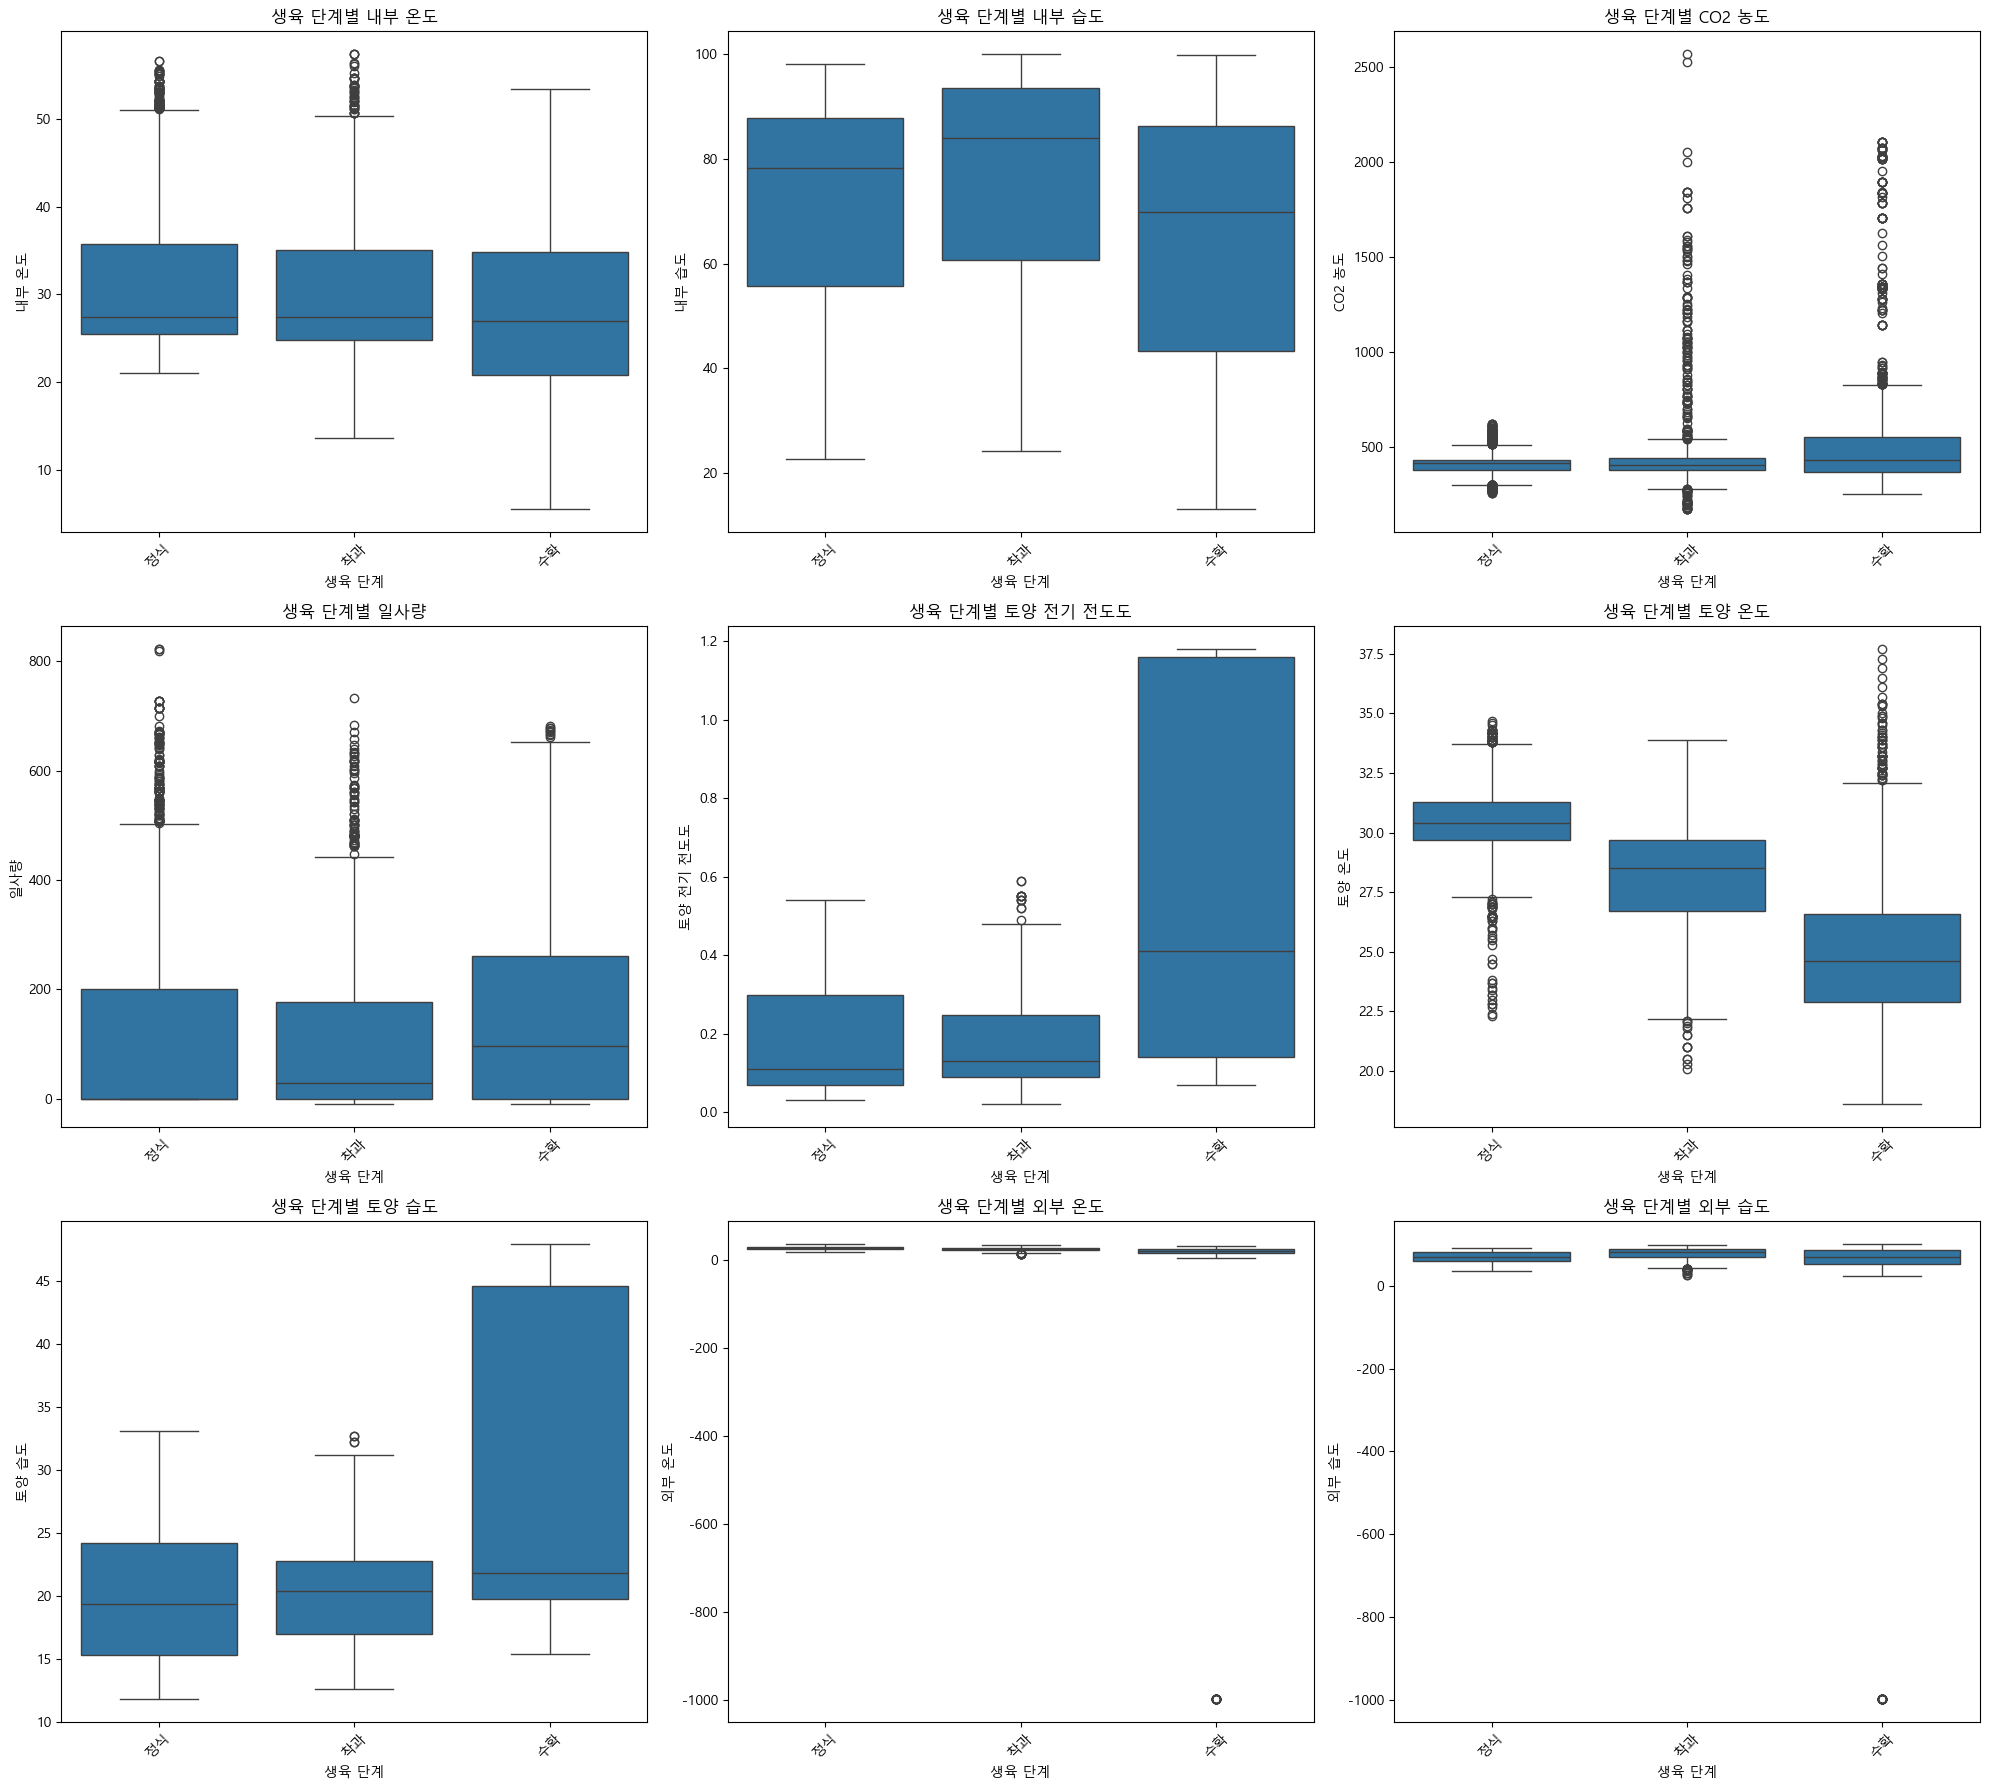

In [40]:
# 박스플롯 그리기

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_lst):
    sns.boxplot(x=target_column, y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{target_column}별 {col}')
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

In [ ]:
# 생육 단계별 평균과 표준편차 계산
grouped_stats = df.groupby(target_column)[numerical_cols].agg(['mean', 'std'])

display("병해유형별 환경 특성 통계", grouped_stats)

'병해유형별 환경 특성 통계'

내부 온도                내부 습도                 CO2 농도              \
            mean       std       mean        std        mean         std   
생육 단계                                                                      
수확     27.599546  9.878591  64.764699  23.827905  506.788604  275.816034   
정식     31.069734  7.731338  71.491919  20.014202  409.877119   69.017499   
착과     30.269498  8.447994  75.670077  20.919682  453.748391  234.369017   

              일사량             토양 전기 전도도                토양 온도            \
             mean         std      mean       std       mean       std   
생육 단계                                                                    
수확     145.620562  154.895582  0.581664  0.464951  24.881998  2.879334   
정식     111.121368  166.715673  0.176513  0.139757  30.489709  1.400483   
착과     109.206564  151.252020  0.171680  0.122612  28.158494  2.275462   

           토양 습도                 외부 온도                 외부 습도              
            mean        std       mean        std       mean         std  
생육 단계                                                                     
수확     29.895582  12.307231  11.552725  96.950142  58.968621  102.947807  
정식     19.983747   5.191807  27.667070   3.103121  68.701574   13.476522  
착과     20.434685   4.044626  25.485071   3.628122  77.359073   14.275634

내부 온도: p-value = 0.0000
내부 습도: p-value = 0.0000
CO2 농도: p-value = 0.0000
일사량: p-value = 0.0000
토양 전기 전도도: p-value = 0.0000
토양 온도: p-value = 0.0000
토양 습도: p-value = 0.0000
외부 온도: p-value = 0.0000
외부 습도: p-value = 0.0000
